# Lab 2: Gene Expression in Human Airway Cells

## Research question

Which genes have the largest differences in average expression between dexamethasone-treated and untreated human airway smooth-muscle cells?

## Data source

This analysis uses the publicly available processed FPKM gene-expression matrix from NCBI GEO study GSE52778.

## Analysis plan

Calculate average expression across four treated and four untreated samples, compare the averages, and visualize the largest changes. This is a descriptive comparison, not a test of statistical significance.

In [27]:
import pandas as pd

url = (
    "https://www.ncbi.nlm.nih.gov/geo/download/"
    "?acc=GSE52778&format=file&file=GSE52778_All_Sample_FPKM_Matrix.txt.gz"
)

fpkm = pd.read_csv(url, sep=r"\s+", compression="gzip")

print("Rows and columns:", fpkm.shape)
fpkm.head(3)

Rows and columns: (23273, 41)


,gene_id,tracking_id,class_code,nearest_ref_id,gene_short_name,tss_id,locus,length,coverage,Dex_FPKM,...,Alb_LL11,Alb_LL15,Untreated_LL09,Untreated_LL05,Untreated_LL13,Untreated_LL01,Alb_Dex_LL08,Alb_Dex_LL04,Alb_Dex_LL12,Alb_Dex_LL16
0,1/2-SBSRNA4,1/2-SBSRNA4,-,-,1/2-SBSRNA4,TSS17399,chr4:110351118-110461615,-,-,0.483373,...,0.243635,0.782332,0.418303,0.458863,0.660772,0.530271,0.503827,0.128484,0.138258,0.567435
1,A1BG,A1BG,-,-,A1BG,TSS11073,chr19:58858171-58874214,-,-,4.391180,...,2.519410,3.672300,1.755330,3.049090,3.593690,4.903660,3.524950,5.924110,2.310150,4.957500
2,A1BG-AS1,A1BG-AS1,-,-,A1BG-AS1,TSS13066,chr19:58858171-58874214,-,-,1.226080,...,0.677901,1.102530,0.395713,1.015780,0.954974,0.694731,1.081040,1.436960,0.548984,1.859440


In [28]:
dex_columns = ["Dex_LL14", "Dex_LL06", "Dex_LL02", "Dex_LL10"]

untreated_columns = [
    "Untreated_LL09",
    "Untreated_LL05",
    "Untreated_LL13",
    "Untreated_LL01"
]

analysis = fpkm.copy()

analysis["mean_dex"] = analysis[dex_columns].mean(axis=1)
analysis["mean_untreated"] = analysis[untreated_columns].mean(axis=1)

analysis[["gene_short_name", "mean_dex", "mean_untreated"]].head()

,gene_short_name,mean_dex,mean_untreated
0,1/2-SBSRNA4,0.471302,0.517052
1,A1BG,4.092238,3.325443
2,A1BG-AS1,1.244652,0.765300
3,A1CF,0.002699,0.004628
4,A2LD1,2.064377,1.970195


In [29]:
import numpy as np

analysis["log2_fold_change"] = np.log2(
    (analysis["mean_dex"] + 0.1) /
    (analysis["mean_untreated"] + 0.1)
)

analysis[
    ["gene_short_name", "mean_dex", "mean_untreated", "log2_fold_change"]
].head()

,gene_short_name,mean_dex,mean_untreated,log2_fold_change
0,1/2-SBSRNA4,0.471302,0.517052,-0.111138
1,A1BG,4.092238,3.325443,0.291430
2,A1BG-AS1,1.244652,0.765300,0.635961
3,A1CF,0.002699,0.004628,-0.026852
4,A2LD1,2.064377,1.970195,0.064185


In [30]:
expressed_genes = analysis[
    (analysis["mean_dex"] >= 1) |
    (analysis["mean_untreated"] >= 1)
].copy()

expressed_genes["absolute_change"] = (
    expressed_genes["log2_fold_change"].abs()
)

top_genes = expressed_genes.nlargest(10, "absolute_change")

top_genes[["gene_short_name", "log2_fold_change"]]

,gene_short_name,log2_fold_change
19397,SNORD54,-17.451483
6777,FTL,16.580435
16896,QSOX1,-14.946527
3909,COL1A2,13.973377
19361,SNORD29,13.969637
12560,MIR374C,13.770989
13163,MIR611,-13.506044
19454,SNORD98,-13.506044
12802,MIR4524A,-13.376943
12333,MIR24-1,13.326174


In [31]:
top_genes[
    ["gene_short_name", "mean_dex", "mean_untreated", "log2_fold_change"]
]

,gene_short_name,mean_dex,mean_untreated,log2_fold_change
19397,SNORD54,0.0000,17923.275000,-17.451483
6777,FTL,9799.4975,0.000000,16.580435
16896,QSOX1,0.0000,3157.470000,-14.946527
3909,COL1A2,1608.3425,0.000000,13.973377
19361,SNORD29,8959.4500,0.458479,13.969637
12560,MIR374C,1397.8150,0.000000,13.770989
13163,MIR611,0.0000,1163.287500,-13.506044
19454,SNORD98,0.0000,1163.287500,-13.506044
12802,MIR4524A,0.0000,1063.702500,-13.376943
12333,MIR24-1,5387.0200,0.424540,13.326174


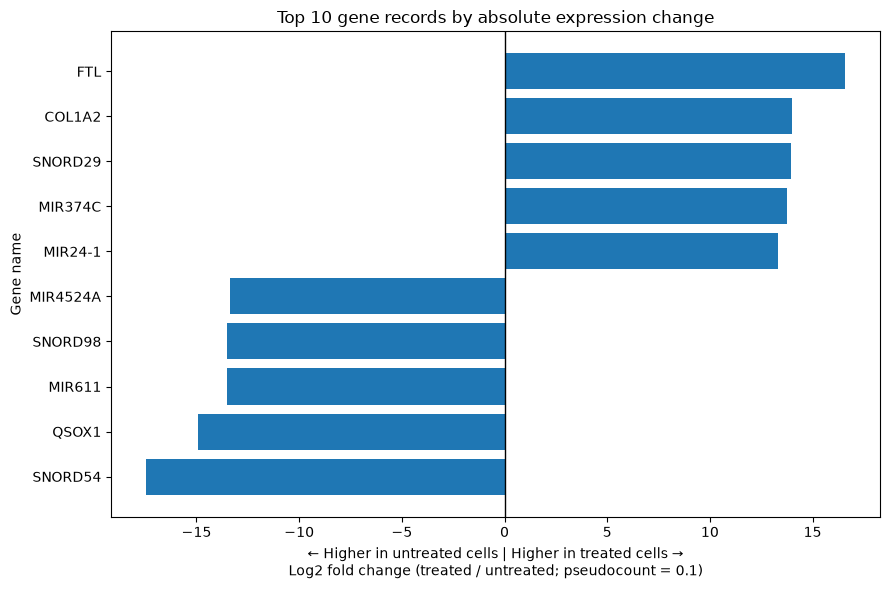

In [32]:
import matplotlib.pyplot as plt

plot_data = top_genes.sort_values("log2_fold_change")

plt.figure(figsize=(9, 6))
plt.barh(
    plot_data["gene_short_name"],
    plot_data["log2_fold_change"]
)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel(
    "← Higher in untreated cells | Higher in treated cells →\n"
    "Log2 fold change (treated / untreated; pseudocount = 0.1)"
)
plt.ylabel("Gene name")
plt.title("Top 10 gene records by absolute expression change")
plt.tight_layout()
plt.show()

## Interpretation

FTL: I observed higher average expression in treated cells.
SNORD54: I observed lower average expression in treated cells.
When one group’s average was zero, the calculated fold change was sensitive to the pseudocount of 0.1.
This analysis compared average expression but did not test statistical significance.

## AI assistance

I used ChatGPT to help write and explain the Python code for loading the dataset, calculating group averages and log2 fold changes, selecting records, and creating the visualization. ChatGPT also helped troubleshoot the data separator and missing Matplotlib package and clarify the chart labels. I ran the code and inspected the resulting tables and chart.

## Python–R comparison

There were matching group mean values, the top ten values, and the log2 fold changes between Python and R.
The outputs seem equally reliable since the methods used were identical; however, none of the analyses checked for significance,
and zero values made some of the fold changes susceptible to the pseudocount value.
Python was faster for me to write because I am more familiar with its syntax,
which made selecting columns and calculating group averages easier for me.